# Smoker Charges: Linear Regression Baseline

This notebook builds a simple baseline model to predict insurance charges for smokers using age as the single feature.

Reason: load libraries and the dataset.

In [30]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

medical_df = pd.read_csv('medical.csv')

## Filter to smoker cohort

We focus on rows where `smoker` is `yes` to isolate a consistent subpopulation.

In [31]:
smoker_df = medical_df[medical_df['smoker'] == 'yes']

## Model choice

Use ordinary least squares linear regression as a transparent, interpretable baseline.

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
model = LinearRegression()

## Train the model

Fit charges as a linear function of age.

Reason: set up features and fit a baseline model.

In [34]:
input = smoker_df[['age']]
target = smoker_df['charges']
model.fit(input, target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Predict and evaluate

Generate in-sample predictions and compute RMSE to summarize fit quality.

Reason: generate predictions and measure error.

In [35]:
predicted_charges = model.predict(input)

In [36]:
def rmse(predictions, actual):
    return np.sqrt(np.mean((predictions - actual) ** 2))

In [37]:
print('w =', model.coef_[0])
print('b =', model.intercept_)
print('RMSE =', rmse(predicted_charges, target))

w = 305.23760210982874
b = 20294.12812691597
RMSE = 10711.00334810241


## Visual check

Plot actual vs. predicted charges across age.

Reason: visually compare predicted vs actual charges.

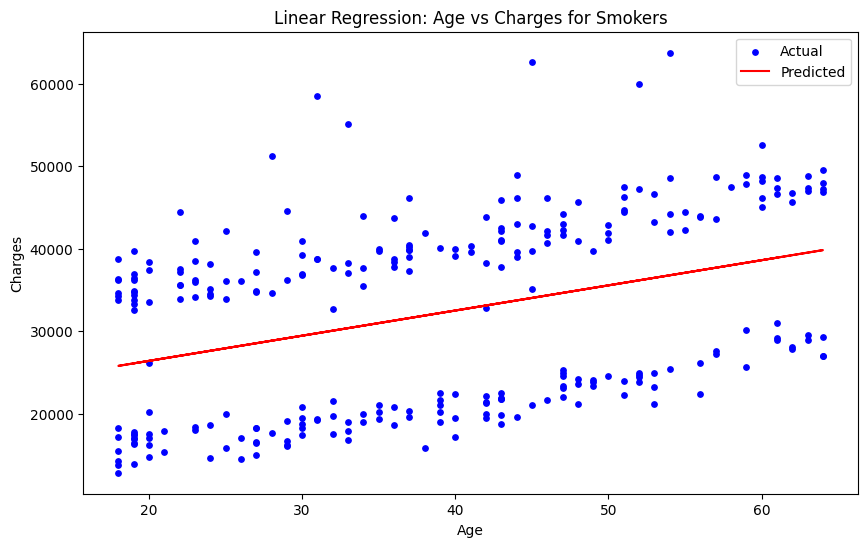

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(input, target, color='blue', label='Actual',s=15)
plt.plot(input, predicted_charges, color='red', label='Predicted')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Linear Regression: Age vs Charges for Smokers')
plt.legend()
plt.show()
